### Crypto-ML-Pairs-Trading (CLEAN) (Perp. Futures) (BinanceEX/HyperLiquid)

<b><u> Statistical-Arbitraging </u></b>

1. Start beta-neutral to isolate and test if strategy generates true alpha, independent of market moves.

2. Evaluate signal quality, if consistent alpha shows up, it's a valid edge and not just hidden beta.

3. Add back beta exposure (e.g., via index ETFs) to scale returns, creating a robust (beta + alpha) portfolio.

<p align="center">
  <span style="font-size:24px; font-weight:bold;"> Trade System Architecture (R&D) </span><br>
  <img src="../theory/ML-pairs-open-arch.png" width="40%">
</p>


<mark> Notes to Remember </mark>

1. Rigorous backtesting of Black Swan events (events with extremely high spreads, uneven order book lots, and the potential to break the algorithm).

2. Out-of-sample backtesting to prevent overfitting to specific events, use independent data sample chunks.

3. Volatility modelling is very important.

#### Research

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import os
from pprint import pprint
import seaborn as sns

from IPython.display import display
import time
from warnings import filterwarnings
import importlib
import pickle
import json
import os
from dotenv import load_dotenv
load_dotenv()


filterwarnings('ignore') 

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [5]:
import utils
import utils.methods
import utils.retrieve
import utils.cluster
import utils.benchmark
import utils.portfolio
import utils.position

importlib.reload(utils.methods)
importlib.reload(utils.retrieve)
importlib.reload(utils.cluster)
importlib.reload(utils.benchmark)
importlib.reload(utils.portfolio)
importlib.reload(utils.position)

<module 'utils.position' from 'c:\\Users\\Alik\\Desktop\\M_year\\MPhil\\Options\\Quant&Finance\\QRT_Acad\\ML-Pairs-Open\\Research\\utils\\position.py'>

In [6]:
from utils.methods import *
from utils.retrieve import *
from utils.cluster import *
from utils.benchmark import *
from utils.portfolio import *
from utils.position import *

In [7]:
with open("config.json", "r") as f:
    config = json.load(f)

# Access variables
data_config = config['data_init']
const_inner_col = data_config["cryp_tmp_fields"]
cryp_market = data_config["cryp_benchmark"]
start = data_config["start"]
end = data_config["end"]
day_limit = data_config["day_limit"]
variance_perc = data_config["variance_perc"]
cluster_distance_threshold = data_config["cluster_distance_threshold"]
cluster_percentile = data_config["cluster_percentile"]

print(const_inner_col, start, end)

['close', 'open', 'high', 'low', 'volume'] 2021-01-01 2024-12-31


Data-Load (BinanceEX API)

In [8]:
stable_ticker = 'USDC/USDT'
history_limit = 1000

In [9]:
df_cryp_uni, cryp_uni_list = get_ccxt_crypto_data(timeframe='1d', limit=history_limit, is_plot=False, load_universe=True)

stablecoin_df = df_cryp_uni.loc[stable_ticker]

df_cryp_uni.drop([stable_ticker], axis=0)
cryp_uni_list = [c for c in cryp_uni_list if c not in [stable_ticker]]

USDT-markets-retrieved:  597 ['BTC/USDT', 'ETH/USDT']
Batch fetch_tickers failed: binance GET https://api.binance.com/api/v3/ticker/24hr?symbols=%5B%22BTCUSDT%22%2C%22ETHUSDT%22%2C%22BNBUSDT%22%2C%22BCCUSDT%22%2C%22NEOUSDT%22%2C%22LTCUSDT%22%2C%22QTUMUSDT%22%2C%22ADAUSDT%22%2C%22XRPUSDT%22%2C%22EOSUSDT%22%2C%22TUSDUSDT%22%2C%22IOTAUSDT%22%2C%22XLMUSDT%22%2C%22ONTUSDT%22%2C%22TRXUSDT%22%2C%22ETCUSDT%22%2C%22ICXUSDT%22%2C%22VENUSDT%22%2C%22NULSUSDT%22%2C%22VETUSDT%22%2C%22PAXUSDT%22%2C%22BCHABCUSDT%22%2C%22BCHSVUSDT%22%2C%22USDCUSDT%22%2C%22LINKUSDT%22%2C%22WAVESUSDT%22%2C%22BTTUSDT%22%2C%22USDSUSDT%22%2C%22ONGUSDT%22%2C%22HOTUSDT%22%2C%22ZILUSDT%22%2C%22ZRXUSDT%22%2C%22FETUSDT%22%2C%22BATUSDT%22%2C%22XMRUSDT%22%2C%22ZECUSDT%22%2C%22IOSTUSDT%22%2C%22CELRUSDT%22%2C%22DASHUSDT%22%2C%22NANOUSDT%22%2C%22OMGUSDT%22%2C%22THETAUSDT%22%2C%22ENJUSDT%22%2C%22MITHUSDT%22%2C%22MATICUSDT%22%2C%22ATOMUSDT%22%2C%22TFUELUSDT%22%2C%22ONEUSDT%22%2C%22FTMUSDT%22%2C%22ALGOUSDT%22%2C%22USDSBUSDT%22%2C%22GTOU

open     high      low    close        volume
symbol   datetime                                                    
ETH/USDT 2022-11-10  1102.73  1350.00  1085.93  1299.28  1.975956e+06
         2022-11-11  1299.28  1310.00  1201.26  1289.28  1.308087e+06
         2022-11-12  1289.35  1292.16  1238.70  1257.25  5.477729e+05
         2022-11-13  1257.25  1274.23  1200.66  1221.49  5.474105e+05
         2022-11-14  1221.50  1291.20  1171.13  1243.28  9.347420e+05

In [10]:
print('Selected-coins (except market & stable): ', len(cryp_uni_list), cryp_uni_list[:5])
print()
display(df_cryp_uni.head(2))
print()
display(stablecoin_df.head(2))

Selected-coins (except market & stable):  95 ['ETH/USDT', 'BTC/USDT', 'XRP/USDT', 'SOL/USDT', 'LTC/USDT']



open    high      low    close        volume
symbol   datetime                                                   
ETH/USDT 2022-11-10  1102.73  1350.0  1085.93  1299.28  1.975956e+06
         2022-11-11  1299.28  1310.0  1201.26  1289.28  1.308087e+06

,open,high,low,close,volume
datetime,,,,,
2022-05-29,1.0011,1.0012,1.0009,1.0010,148829313.0
2022-05-30,1.0010,1.0011,1.0005,1.0008,336531173.0


#### ~2.5 Years API Call-Limit
Different tokens got listed at different times in Binance, and some got de-listed at different times 

Rnd-Coin-Chosen:  DAR/USDT


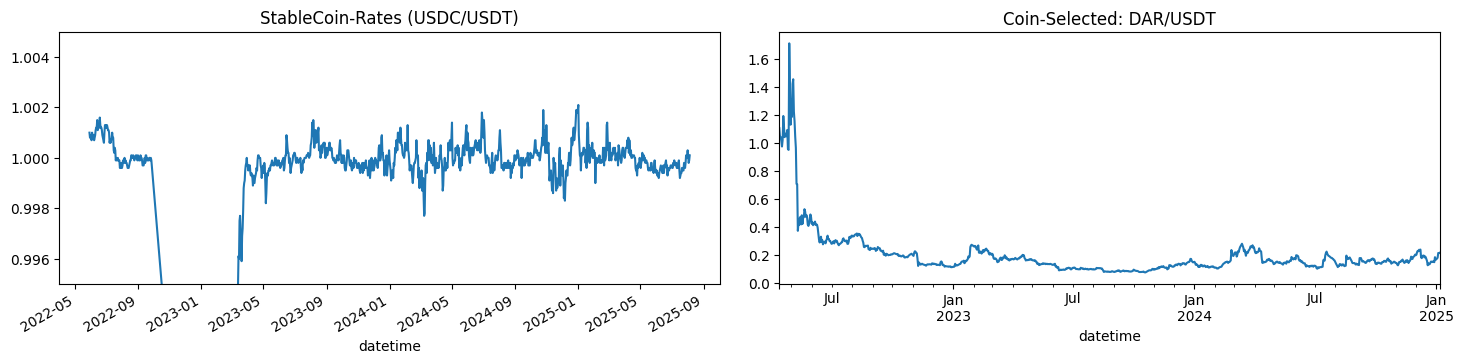

In [11]:
rn_coin = random.randint(0, len(cryp_uni_list))
rn_coin = cryp_uni_list[rn_coin]
print('Rnd-Coin-Chosen: ', rn_coin)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

stablecoin_df.close.plot(ax=axs[0])
axs[0].set_title('StableCoin-Rates (USDC/USDT)')
axs[0].set_ylim(0.995, 1.005)

df_cryp_uni.loc[rn_coin].close.plot(ax=axs[1])
axs[1].set_title(f'Coin-Selected: {rn_coin}')

plt.tight_layout(pad=2)
plt.show()

In [12]:
sub_sample = 20

In [13]:
# stocks = np.random.choice(np.array(cryp_uni_list), size=sub_sample).tolist()
stocks = cryp_uni_list[:sub_sample]
print('sampled-selected: ', stocks)

df_uni = df_cryp_uni.copy()
df_uni = df_uni.loc[stocks]

df_cleaned = []
for nm in stocks:
    df_filtered = df_uni.loc[nm].copy()
    df_filtered = df_filtered[~df_filtered.index.duplicated(keep='first')]
    df_filtered['symbol'] = nm  
    df_cleaned.append(df_filtered)

# Combine and set multi-index again
df_uni = pd.concat(df_cleaned).set_index('symbol', append=True).swaplevel()
df_uni = df_uni.sort_index()

display(df_uni.head(3))

sampled-selected:  ['ETH/USDT', 'BTC/USDT', 'XRP/USDT', 'SOL/USDT', 'LTC/USDT', 'DOGE/USDT', 'BNB/USDT', 'TRX/USDT', 'UNI/USDT', 'ADA/USDT', 'CRV/USDT', 'AVAX/USDT', 'XLM/USDT', 'LINK/USDT', 'BCH/USDT', 'ILV/USDT', 'AAVE/USDT', 'OP/USDT', 'APT/USDT', 'NEAR/USDT']


open  high   low  close      volume
symbol    datetime                                       
AAVE/USDT 2022-11-10  58.2  70.9  57.0   68.0  474350.321
          2022-11-11  68.0  68.9  60.5   64.0  281627.934
          2022-11-12  64.1  64.1  56.8   58.1  499358.201

Multi-Visualization (RAW)

LEN_ETH/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_BTC/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_XRP/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_SOL/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_LTC/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_DOGE/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_BNB/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_TRX/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_UNI/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_ADA/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_CRV/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_AVAX/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_XLM/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-05 00:00:00
LEN_LINK/USDT: 1000 | start=2022-11-10 00:00:00, end=2025-08-0

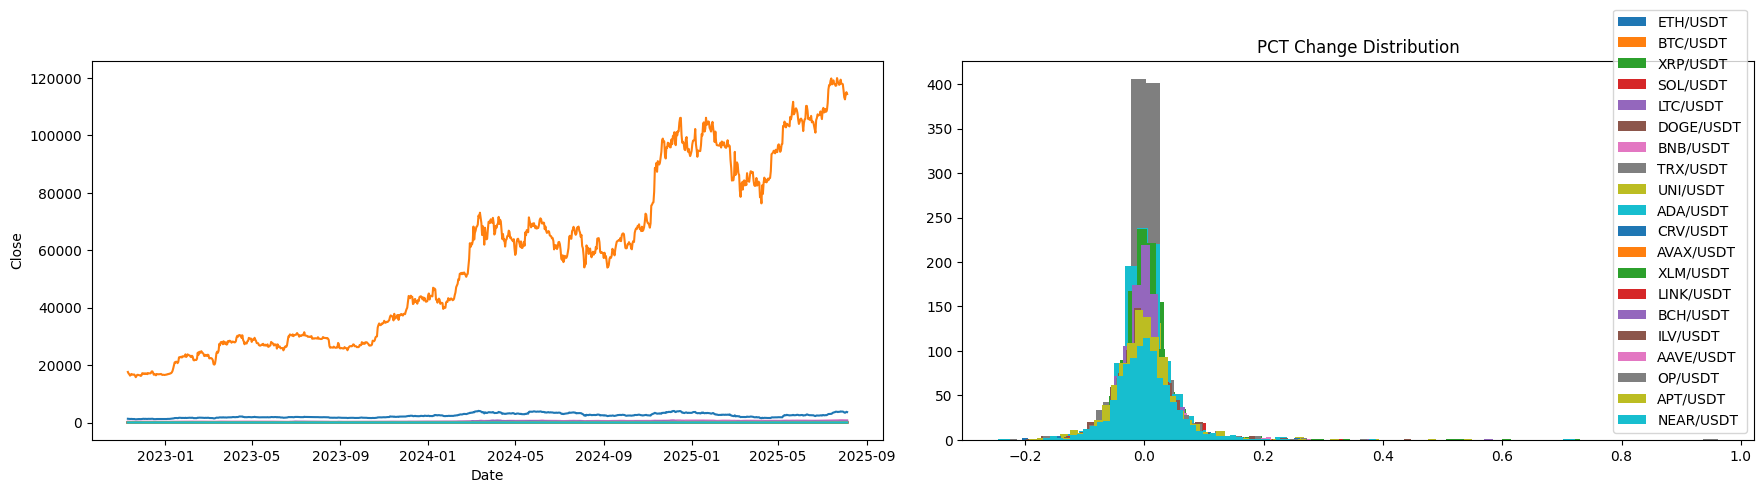

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))

### We just do multi-indexing
for nm in stocks:
    print(f'LEN_{nm}: {len(df_uni.loc[nm].index)} | start={df_uni.loc[nm].index[0]}, end={df_uni.loc[nm].index[-1]}')
    axs[0].plot(df_uni.loc[nm].index, df_uni.loc[nm]['close'], label = nm)
    axs[0].set_xlabel('Date')
    axs[0].set_ylabel('Close')

plt.legend()

for nm in stocks:

    pct_change_clean = df_uni.loc[nm]['close'].pct_change().dropna()

    if pct_change_clean.empty:
        print(f"Skipping {nm} due to no valid percentage change data.")
        continue
    
    axs[1].hist(pct_change_clean, bins = 50, label = nm)
    axs[1].set_title(f'PCT Change Distribution')

plt.tight_layout(pad = 2)
plt.legend()
plt.show()

Data-Cleaning 

In [15]:
## returns factor-arrays (takes types and fundamental_df)
val_arr, stocks = data_clean(df_uni=df_uni, stocks=stocks, history_limit=history_limit, type='cryp', fund_df=None, is_plot=False)
    
print(len(val_arr), len(val_arr[0]))
val_arr = np.array(val_arr)
print(val_arr.shape)

print('New-Stocks: ', stocks)
print(len(stocks))

val_arr = val_arr.reshape(len(stocks), -1)
print(val_arr.shape)

Data-Cleaning ...
time-taken for data-cleaning:  0.0006100654602050782  mins
20 3
(20, 3, 1000)
New-Stocks:  ['ETH/USDT', 'BTC/USDT', 'XRP/USDT', 'SOL/USDT', 'LTC/USDT', 'DOGE/USDT', 'BNB/USDT', 'TRX/USDT', 'UNI/USDT', 'ADA/USDT', 'CRV/USDT', 'AVAX/USDT', 'XLM/USDT', 'LINK/USDT', 'BCH/USDT', 'ILV/USDT', 'AAVE/USDT', 'OP/USDT', 'APT/USDT', 'NEAR/USDT']
20
(20, 3000)


PortFolio-Construction

In [27]:
import utils
import utils.retrieve
import utils.benchmark

importlib.reload(utils.retrieve)
importlib.reload(utils.benchmark)

from utils.retrieve import *
from utils.benchmark import *

In [28]:
import utils

import utils.factor_model
import utils.market_proxy
import utils.alpha_ex
import utils.beta_ex
import utils.portfolio
import utils.risk_engine
import utils.backtest
import utils.forward_test
import utils.analytics

importlib.reload(utils.factor_model)
importlib.reload(utils.market_proxy)
importlib.reload(utils.alpha_ex)
importlib.reload(utils.beta_ex)
importlib.reload(utils.portfolio)
importlib.reload(utils.risk_engine)
importlib.reload(utils.backtest)
importlib.reload(utils.forward_test)
importlib.reload(utils.analytics)

<module 'utils.analytics' from 'c:\\Users\\Alik\\Desktop\\M_year\\MPhil\\Options\\Quant&Finance\\QRT_Acad\\ML-Pairs-Open\\Research\\utils\\analytics.py'>

In [29]:
from utils.factor_model import *
from utils.alpha_ex import *
from utils.beta_ex import *
from utils.portfolio import *
from utils.risk_engine import *
from utils.backtest import *
from utils.forward_test import *
from utils.analytics import *
from utils.market_proxy import * 

In [30]:
SEED=68
np.random.seed(seed=SEED)

##### For the research env everything will be executed independently akin to their modularized nature

In [31]:
# 'test_data' to independently check indiviual components
timeline = df_uni.loc[stocks[0]].index
test_time_index = random.randint(0, len(timeline) - 1)
test_time = timeline[test_time_index]

print('test_time/test_time_index: ', test_time, '|', test_time_index, '|', type(test_time))
display(df_uni.head(3))

test_time/test_time_index:  2024-09-12 00:00:00 | 672 | <class 'pandas._libs.tslibs.timestamps.Timestamp'>


open  high   low  close      volume
symbol    datetime                                       
AAVE/USDT 2022-11-10  58.2  70.9  57.0   68.0  474350.321
          2022-11-11  68.0  68.9  60.5   64.0  281627.934
          2022-11-12  64.1  64.1  56.8   58.1  499358.201

Synthetic-Index-Retrieval

In [32]:
from utils.market_proxy import *

Beta-Basket:  ['BTC/USDT', 'ETH/USDT', 'SOL/USDT']


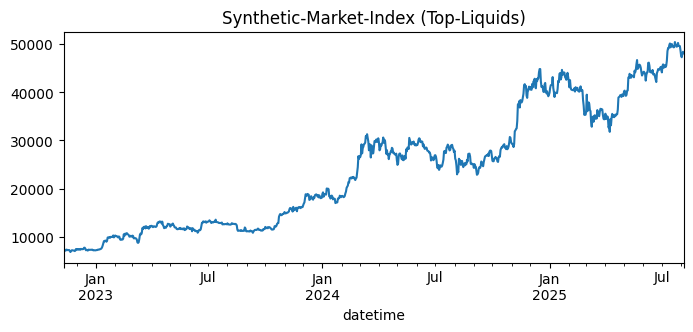

In [33]:
market = MarketProxy(df_cryp_uni, top_n=3)

## index-weightage is independent of token-metadata (so NOT Ideal)
market_df, beta_basket = market.get_syn_index(ret_beta_basket=True)

print('Beta-Basket: ', beta_basket)

fig = plt.figure(figsize=(8, 3))
market_df.plot()
plt.title('Synthetic-Market-Index (Top-Liquids)')
plt.show()

In [34]:
## Call factor_model and pass the retrieved clean/data
factor_model = FactorModelPairs(stocks, variance_perc, is_plot=False)
pairs = factor_model.run(val_arr, df_uni, start_time=test_time, start_time_index=test_time_index)

Decomposed-Dim:  1
Agglom - nunmber of clusters generated:  10
 ---- Clusters ---- 

{5: ['ETH/USDT'], 7: ['BTC/USDT'], 1: ['XRP/USDT', 'DOGE/USDT', 'TRX/USDT', 'ADA/USDT', 'CRV/USDT', 'XLM/USDT', 'OP/USDT', 'NEAR/USDT'], 8: ['SOL/USDT'], 2: ['LTC/USDT', 'AAVE/USDT'], 9: ['BNB/USDT'], 0: ['UNI/USDT', 'LINK/USDT', 'APT/USDT'], 3: ['AVAX/USDT'], 4: ['BCH/USDT'], 6: ['ILV/USDT']}

 ------------- 
Testing cointegration in cluster 1 with 8 symbols.
P-Value:  0.18471441398175936
P-Value:  0.10391603385491222
P-Value:  0.19258335500723917
P-Value:  0.09357937289807483
P-Value:  0.1091536148525124
P-Value:  0.19695287511411746
P-Value:  0.17947639899965206
P-Value:  0.2990941751310334
P-Value:  0.6617940766005463
P-Value:  0.44344665779843145
P-Value:  0.7191956551117349
P-Value:  0.5082306648457313
P-Value:  0.03529349925255097
Cointegrated pair found: DOGE/USDT_NEAR/USDT with p-value 0.03529349925255097 and Hurst -0.00
P-Value:  0.985729834839343
P-Value:  0.270536188041699
P-Value:  0.97142

In [35]:
pprint(pairs[list(pairs.keys())[0]])

{'hedge_ratio': 0.014170474167178424,
 'hurst': -5.667772866533277e-16,
 'spread_mean': 0.043850207720375324,
 'spread_series': datetime
2022-11-10    0.056975
2022-11-11    0.054893
2022-11-12    0.059809
2022-11-13    0.057275
2022-11-14    0.058020
                ...   
2024-09-07    0.043427
2024-09-08    0.042936
2024-09-09    0.046880
2024-09-10    0.045650
2024-09-11    0.045082
Name: close, Length: 672, dtype: float64,
 'spread_std': 0.003277077667269227,
 'symbol_x': 'NEAR/USDT',
 'symbol_y': 'DOGE/USDT'}


Predictive-Arbitrage (Alpha/Beta-Ex -> Risk-Engine)

In [36]:
initial_positions = {} ## No-Position
lookback_window = 60
entry_z = 2.5 
exit_z = 0.5

alpha_alloction = 0.4 ## max-portfolio-weight-allocation for alpha
beta_allocation = 0.6 ## max-portfolio-weight-allocation for beta

In [39]:
portfolio_config = config['portfolio_init']
portfolio_config['strategy']['beta_basket'] = beta_basket

pprint(portfolio_config)

{'alpha': {'past_window': 60},
 'optimizer': {'max_adv_fraction': 0.025,
               'max_leverage_alpha': 1.0,
               'optimizer_method': 'SLSQP',
               'target_beta': 0.0},
 'strategy': {'alpha_allocation': 0.7,
              'beta_allocation': 0.3,
              'beta_basket': ['BTC/USDT', 'ETH/USDT', 'SOL/USDT']}}


In [40]:
## Call alpha_ex and pass the coint_pairs
alpha = PairsTradingAlpha(pairs, lookback_window=lookback_window, entry_z=entry_z, exit_z=exit_z)
target_position_alpha = alpha.generate_signal(timestamp=test_time, current_positions=initial_positions)

print('alpha-target-position: ', target_position_alpha)

alpha-target-position:  {'DOGE/USDT_NEAR/USDT': 0}


In [41]:
## Call beta_ex and get the beta_exposure
beta = SimpleMarketBeta(market_proxy = market_df, fast_ma_period = 25, slow_ma_period = 120)
target_position_beta = beta.generate_signal(timestamp=test_time, prev_signal=0)

print('beta-target-position: ', target_position_beta)

beta-target-position:  -1.0


In [42]:
## Call portfolio and pass the alpha and beta exposure - calculate ideal-portfolio-weight allocation 
portfolio = PortfolioConstructor(pairs_data=pairs, history_data=df_uni, market_data=market_df, config=portfolio_config)
portfolio_weights = portfolio.construct_target_weights(timestamp=test_time, alpha_signals=target_position_alpha, beta_signal=target_position_beta)
print('portfolio_weights: ', portfolio_weights)

portfolio_weights:  {'BTC/USDT': -0.09999999999999999, 'ETH/USDT': -0.09999999999999999, 'SOL/USDT': -0.09999999999999999}


#### Verbose-Portfolio-State

<code> 
random_portfolio_state = {
    # --- Portfolio-Level Financials ---
    "equity": 108500.00,
    "cash": 65000.00,  # Capital not currently used as margin
    "high_water_mark": 120000.00,  # All-time high equity

    # --- Portfolio-Level Risk Metrics ---
    # Calculated from the positions below
    "drawdown": 0.0958,  # (1 - 108500 / 120000). Set close to a 10% limit.
    "leverage": 0.8,     # Gross leverage from all asset exposures.

    # --- Core Positions Dictionary (keyed by PAIR) ---
    "positions": {
        'BTCUSDT-ETHUSDT': {
            'status': 'ACTIVE_LONG', # Human-readable status
            'signal': 1,             # The raw signal that initiated this position
            'pair_weight': 0.4,      # The capital allocated to this specific pair trade
            'asset_positions': {     # The actual resulting asset holdings
                'BTCUSDT': { 'size': 0.3, 'entry_price': 61000.00 },
                'ETHUSDT': { 'size': -5.1, 'entry_price': 3000.00 } # Hedge ratio = 17
            }
        },
        'SOLUSDT-AVAXUSDT': {
            'status': 'ACTIVE_SHORT',
            'signal': -1,
            'pair_weight': 0.4,
            'asset_positions': {
                'SOLUSDT': { 'size': -60.0, 'entry_price': 150.00 },
                'AVAXUSDT': { 'size': 180.0, 'entry_price': 30.00 } # Hedge ratio = 5
            }
        }
        # Note: A pair like 'LINKUSDT-UNIUSDT' might be flat (not in the dict)
    }
}
</code>

Simplified-P-State

In [43]:
random_portfolio_state = {
    # --- Portfolio-Level Financials ---
    "equity": 108500.00,
    "cash": 65000.00,  # Capital not currently used as margin
    "high_water_mark": 120000.00,  # All-time high equity (all-time-high-value-portfolio-has-reached)

    # --- Portfolio-Level Risk Metrics ---
    "drawdown": 0.0958,  
    
    # --- Core Positions Dictionary (keyed by PAIR) ---
    "positions": {
                'BTC/USDT': { 'size': 0.3, 'value': 30000.00 },
                'ETH/USDT': { 'size': -5.1, 'value': 3000.00 },
                'SOL/USDT': { 'size': -60.0, 'value': 150.00 },
                'AVAX/USDT': { 'size': 180.0, 'value': 30.00 }
        }
}

In [44]:
import utils.risk_engine
importlib.reload(utils.risk_engine)
from utils.risk_engine import *

In [45]:
## Call risk_engine and add execution/liquidity/volume/positional caps/constraints
risk_manager = RiskManager(max_leverage=1.0, max_concentration=0.5, max_portfolio_drawdown=0.10)
hedged_portfoilo_weights = risk_manager.manage_weights(target_weights=portfolio_weights, portfolio_state=random_portfolio_state)
print("hedged_portfoilo_weights: ", hedged_portfoilo_weights)

hedged_portfoilo_weights:  {'BTC/USDT': -0.09999999999999999, 'ETH/USDT': -0.09999999999999999, 'SOL/USDT': -0.09999999999999999, 'AVAX/USDT': 0.00027649769585253456}


PORTFOLIO-Backtesting

In [46]:
# --- 2. Define Configuration ---
FEE_CONFIG = {'maker': 0.00018, 'taker': 0.00045}
INITIAL_CAPITAL = 100000.0

In [47]:
start = df_uni.loc[stocks[0]].index[0]
end = df_uni.loc[stocks[0]].index[-1]

print(f'start: {start}, end: {end}')

start: 2022-11-10 00:00:00, end: 2025-08-05 00:00:00


In [48]:
import utils
import utils.fees_model

importlib.reload(utils.fees_model)
from utils.fees_model import *

In [49]:
from binance.client import Client

In [50]:
api_key = os.environ.get('BINANCE_API_KEY')
api_secret = os.environ.get('BINANCE_API_SECRET')

In [51]:
client = Client(api_key, api_secret)

##### Funding rates are published every 8 hours (3 times per day).
##### We aggregate these to compute the net daily funding by summing the values within each calendar day.

In [52]:
fees_model = FeesModel()
funding_df = fees_model.get_funding_rate_history(client, stocks, start, end)

print()
print('Before-CHANGE: ')
display(funding_df.head(3))

print()
new_index = [(s[:-4] + '/' + s[-4:], ts) for s, ts in funding_df.index]
funding_df.index = pd.MultiIndex.from_tuples(new_index, names=funding_df.index.names)

print('After-CHANGE: ')
display(funding_df.head(3))

Fetching historical funding rates...
  - Fetching for ETHUSDT
  - Fetching for BTCUSDT
  - Fetching for XRPUSDT
  - Fetching for SOLUSDT
  - Fetching for LTCUSDT
  - Fetching for DOGEUSDT
  - Fetching for BNBUSDT
  - Fetching for TRXUSDT
  - Fetching for UNIUSDT
  - Fetching for ADAUSDT
  - Fetching for CRVUSDT
  - Fetching for AVAXUSDT
  - Fetching for XLMUSDT
  - Fetching for LINKUSDT
  - Fetching for BCHUSDT
  - Fetching for ILVUSDT
  - Fetching for AAVEUSDT
  - Fetching for OPUSDT
  - Fetching for APTUSDT
  - Fetching for NEARUSDT
Funding data successfully aggregated to daily and multi-indexed.

Before-CHANGE: 


fundingRate
symbol  date                   
ETHUSDT 2022-11-10    -0.001299
        2022-11-11    -0.000275
        2022-11-12     0.000248


After-CHANGE: 


fundingRate
symbol   date                   
ETH/USDT 2022-11-10    -0.001299
         2022-11-11    -0.000275
         2022-11-12     0.000248

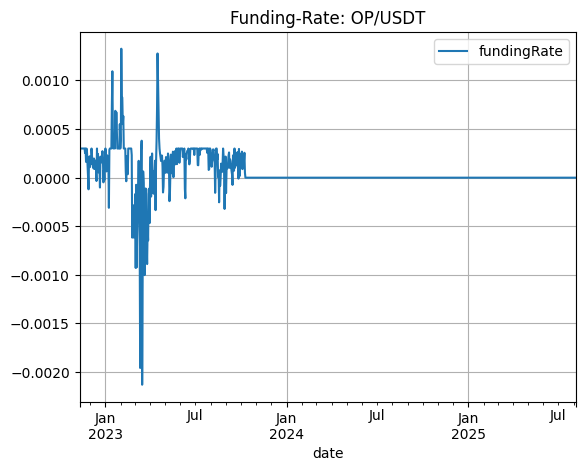

2022-11-10 00:00:00


In [ ]:
rn = random.randint(0, len(stocks) - 1)
test_token = stocks[rn]

fig = plt.Figure(figsize = (4, 3))

funding_df.loc[test_token].plot()
plt.title(f'Funding-Rate: {test_token}')

plt.grid()
plt.show()

Binance/API-deprec. point

In [156]:
temp_df = funding_df.loc[test_token]

is_zero = temp_df['fundingRate'] == 0

group = (is_zero != is_zero.shift()).cumsum()
zero_runs = is_zero.groupby(group).sum()

long_zero_groups = zero_runs[zero_runs > 40]

if not long_zero_groups.empty:
    first_group_label = long_zero_groups.index[0]
    mask = group == first_group_label
    api_dep = temp_df.index[mask][0]
    print("API-deprecation-Point:", api_dep)
else:
    print("API is fine")

API-deprecation-Point: 2023-10-10 00:00:00


We are witnessing here the artifact of deprecated API endpoint - Need to use <code>ccxt</code> library for USD-(M) (settled in USDT)

In [128]:
import utils.backtest
importlib.reload(utils.backtest)
from utils.backtest import * 

In [129]:
alpha_generator = PairsTradingAlpha(
    pairs_data=pairs, 
    lookback_window=60, 
    entry_z=2.0, 
    exit_z=0.5
)

beta_generator = SimpleMarketBeta(
    market_proxy = market_df,
    fast_ma_period = 25, 
    slow_ma_period = 120
)            

portfolio_constructor = PortfolioConstructor(
    pairs_data=pairs, 
    history_data=df_uni,
    market_data=market_df,  
    config=portfolio_config
)

risk_manager = RiskManager(
    max_leverage=1.0,
    max_concentration=0.5,
    max_portfolio_drawdown=0.20
)

# --- 4. Define the Orchestrator Function ---
def orchestrator_function(timestamp, portfolio_state, alpha_signals, beta_signal):
    alpha_signals = alpha_generator.generate_signal(timestamp, alpha_signals)
    beta_signal = beta_generator.generate_signal(timestamp, beta_signal)
    target_weights = portfolio_constructor.construct_target_weights(timestamp, alpha_signals, beta_signal)
    final_weights = risk_manager.manage_weights(target_weights, portfolio_state)
    
    return final_weights, alpha_signals, beta_signal

In [238]:
ft = time.time()

backtester = PerpetualFuturesBacktester(
    initial_capital=INITIAL_CAPITAL,
    fee_config=FEE_CONFIG
)

_ensmb_size = 100 ## random-backtest-chunks
_ensmb_list = []

for i in range(_ensmb_size):
    ## Run an Ensemble of trades
    final_equity_curve = backtester.run(
        history_data=df_uni,
        funding_data=funding_df,
        orchestrator=orchestrator_function
    )
    _ensmb_list.append(final_equity_curve)
    
lt = time.time()
print('time-taken-backtesting: ', (lt - ft)/60, ' mins')

Backtesting ...
start-timestamp:  2024-01-01 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2023-08-06 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2024-02-07 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2024-12-17 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2023-08-14 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2023-04-05 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2023-11-12 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2024-01-04 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2024-10-31 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2024-10-19 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtesting ...
start-timestamp:  2025-04-13 00:00:00
end-timestamp:  2025-08-05 00:00:00
Backtestin

#### Singular-Portfolio

In [239]:
test_portfolio_eq_curve = _ensmb_list[-1] 

In [247]:
plt.style.use('seaborn-v0_8-whitegrid')

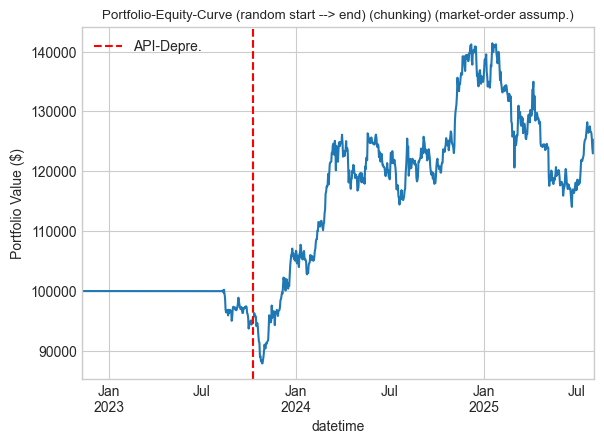

In [250]:
test_portfolio_eq_curve.plot()

plt.axvline(x=api_dep, color='red', linestyle='--', label='API-Depre.')

plt.legend()
plt.title(f'Portfolio-Equity-Curve (random start --> end) (chunking) (market-order assump.)', fontsize=9.5)
plt.ylabel('Portfolio Value ($)')
plt.tight_layout(pad=2)
plt.show()

#### Multiple-Portfolio Realizations

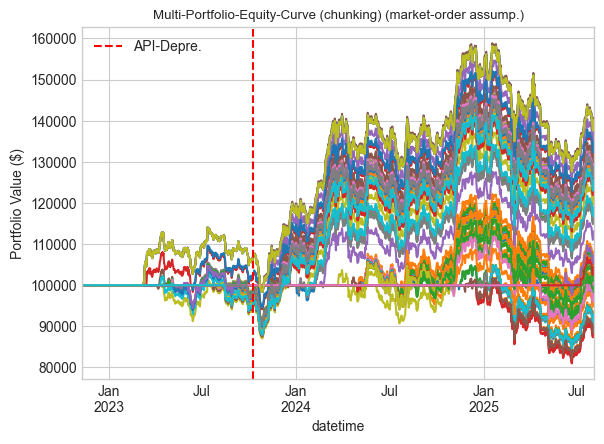

In [251]:
for eq_curve in _ensmb_list:
    eq_curve.plot()

plt.axvline(x=api_dep, color='red', linestyle='--', label='API-Depre.')

plt.legend()
plt.title(f'Multi-Portfolio-Equity-Curve (chunking) (market-order assump.)', fontsize=9.5)
plt.ylabel('Portfolio Value ($)')
plt.tight_layout(pad=2)
plt.show()

We need to see if our strat. beats the market rates (alpha + beta. layering) - use Information Ration (IR), Sharpe-Ratio for risk-adjusted return (higher return tend to have higher-drawdrowns) - VaR (tail-risk) + CVaR (expected tail-risk losses)

Volatility can be used to detect regime-changes
1. Bull/Bear/Sideways
2. Entry/Exit Thresh.
3. Switch between Mean-Rev (consolidation) & Momentum Trad. 

#### Analytics (Singular)

In [221]:
import utils.analytics
from utils.analytics import *
importlib.reload(utils.analytics)

<module 'utils.analytics' from 'c:\\Users\\Alik\\Desktop\\M_year\\MPhil\\Options\\Quant&Finance\\QRT_Acad\\ML-Pairs-Open\\Research\\utils\\analytics.py'>

In [242]:
## Call/Save analytics on both the tests 
analytics = PortfolioAnalytics(test_portfolio_eq_curve, market_df, periods_per_year=365)

--- Performance Summary ---
Final Portfolio Value: $124,760.10
---------------------------
Compound Annual Growth Rate (CAGR): 8.41%
Annualized Sharpe Ratio: 0.60
Annualized Sortino Ratio: 0.72
Maximum Drawdown: -19.32%
---------------------------
Market Beta: 0.06
Annualized Alpha: 5.12%
---------------------------


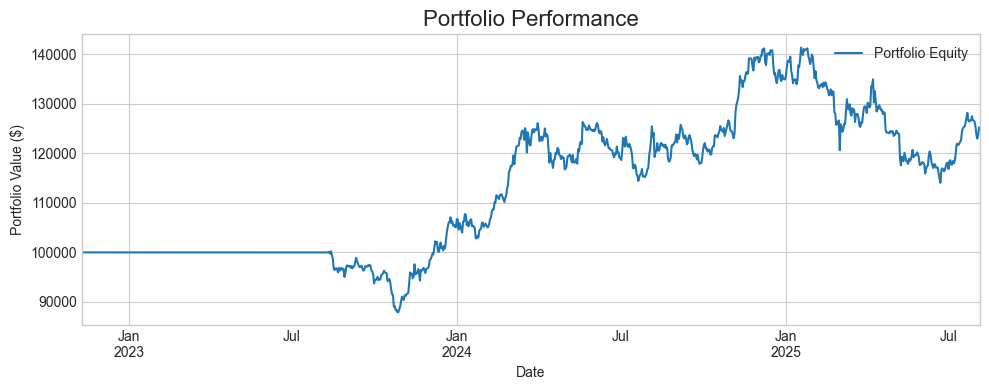

In [243]:
analytics.display_summary()

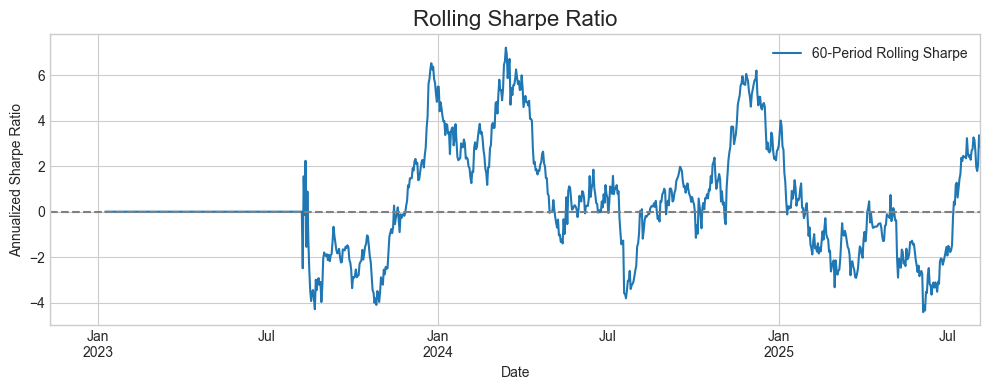

In [244]:
analytics.plot_rolling_sharpe(window=60) ##2-months-window 

#### Ensemble-Metric/Posterior-Distrib of Backtest-Chunks
this is flawed because it takes different timescales with random inital seed - portfolio-value metric makes no sense - rest do (?) - Portfolio values makes sense if you run different realisation from near time-scles

In [245]:
_ensmb_post = []
for portfolio_eq_curve in _ensmb_list:
    analytics = PortfolioAnalytics(portfolio_eq_curve, market_df, periods_per_year=365)
    _ensmb_dict = analytics.display_summary(is_ensmb=True)
    _ensmb_post.append(list(_ensmb_dict.values()))
    
_ensmb_post = np.array(_ensmb_post).reshape(_ensmb_size, -1)
_ensmb_post = np.swapaxes(_ensmb_post, 0, 1)

print('---- Ensemble-Information (FLAWED - Time/Differention) ----')
print(_ensmb_post.shape)
e_mean, e_std = np.mean(_ensmb_post, axis=-1), np.std(_ensmb_post, axis=-1)
for i, e in enumerate(list(_ensmb_dict.keys())):
    print(f'{e} (mean/std): {e_mean[i]:.2f} +- {e_std[i]:.2f}')     
    


---- Ensemble-Information (FLAWED - Time/Differention) ----
(7, 100)
port_value (mean/std): 113700.44 +- 15391.86
sharpe_ratio (mean/std): 0.36 +- 0.37
sortino_ratio (mean/std): 0.41 +- 0.41
max_drawdown (mean/std): -0.18 +- 0.04
annualizd_compound_return (mean/std): 0.05 +- 0.05
beta (mean/std): 0.03 +- 0.04
ann_alpha (mean/std): 0.03 +- 0.03


Posterior-Distrib. <b> (sharpe-ratio/sortino-ratio/max-drawdown/beta/ann_alpha) </b>

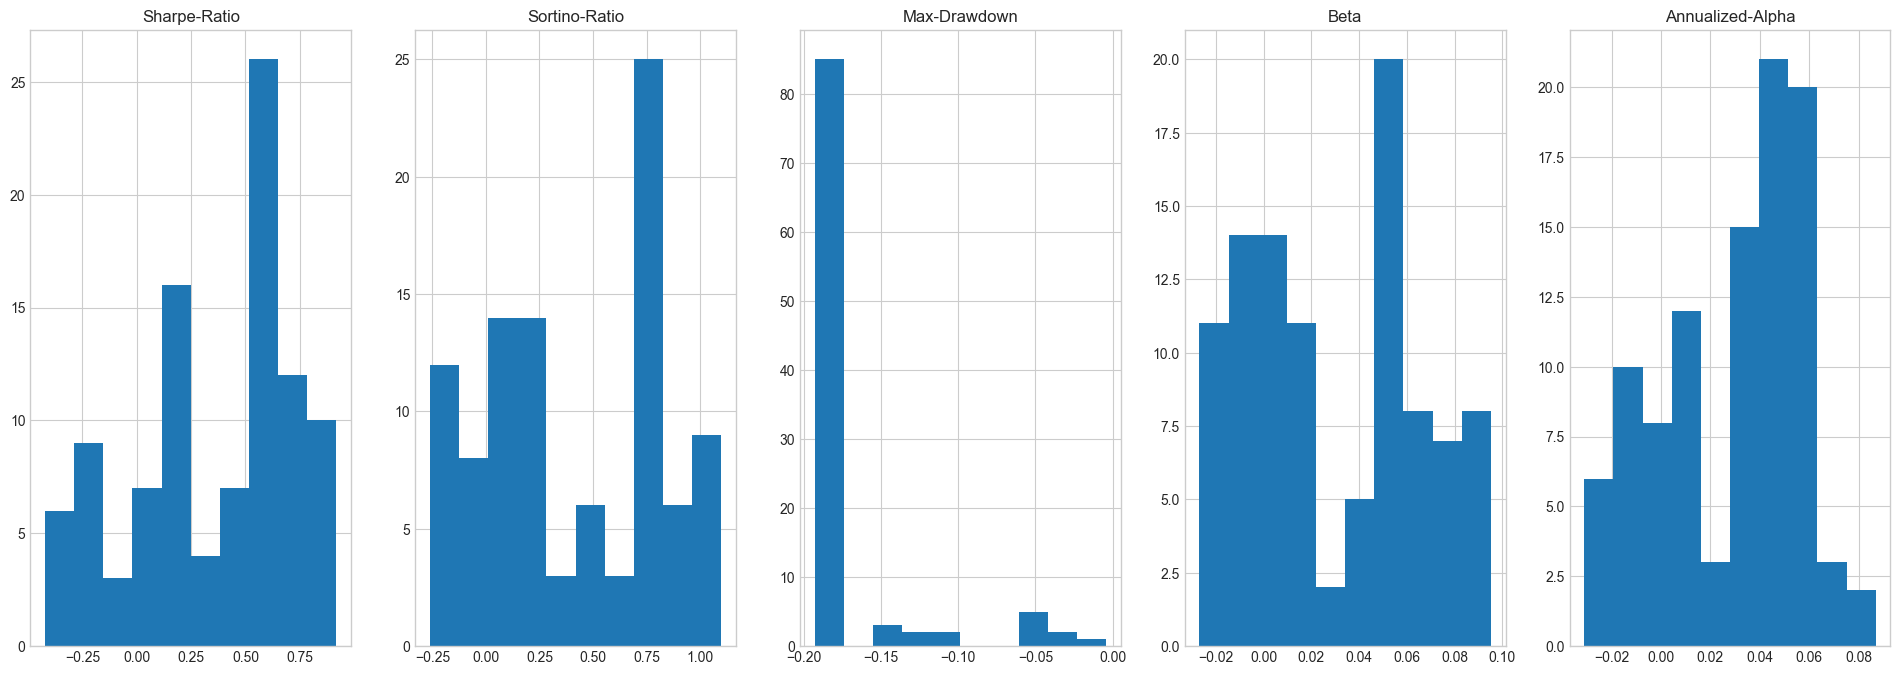

In [257]:
fig, axs = plt.subplots(1, 5, figsize=(24, 8))

rate = 10

axs[0].hist(_ensmb_post[1, :], bins = _ensmb_post.shape[-1]//rate)
axs[0].set_title('Sharpe-Ratio')

axs[1].hist(_ensmb_post[2, :], bins = _ensmb_post.shape[-1]//rate)
axs[1].set_title('Sortino-Ratio')

axs[2].hist(_ensmb_post[3, :], bins = _ensmb_post.shape[-1]//rate)
axs[2].set_title('Max-Drawdown')

axs[3].hist(_ensmb_post[5, :], bins = _ensmb_post.shape[-1]//rate)
axs[3].set_title('Beta')

axs[4].hist(_ensmb_post[6, :], bins = _ensmb_post.shape[-1]//rate)
axs[4].set_title('Annualized-Alpha')

plt.show()

#### Forward-Test / Live-Trading

In [ ]:
from utils.forward_test import *
